# Child model V&V: all-cause mortality

Version-free filename by convention: rerun against each model iteration's results and commit,
so run-over-run diffs fall out of git history. The LBWSG relative-risk and PAF checks that used
to live here moved to `child_lbwsg.ipynb`, which verifies them against a live `InteractiveContext`
of the child model.

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from vivarium.artifact import Artifact

location = "nigeria"
vehicle = "bouillon"
results_dir = "/mnt/team/simulation_science/pub/models/vivarium_gates_lsff_2026/results/model1.1/child/bouillon/nigeria/2026_08_28_20_20_09/results/"
artifact_dir = "/mnt/team/simulation_science/pub/models/vivarium_gates_lsff_2026/artifacts/model1.1/child/bouillon/nigeria.hdf"
art = Artifact(artifact_dir)

## All-cause mortality: sim vs artifact

The artifact rate is drawn as the step function the sim actually looks up (lookup interpolation
is order 0, so the rate is constant within each artifact age bin). The sim's measured
deaths / person-time is drawn as a bar spanning each output age bin, so it is explicit which
artifact bins each sim value mixes together. The dashed line over each bar is the expected
mixture: deaths / person-time over that age range under the artifact's piecewise-constant
hazard (person-time weighting via the implied survival curve) -- the bar should sit on it.
Both first bins start at age 0; the log axis clips their left edge to the plot minimum.

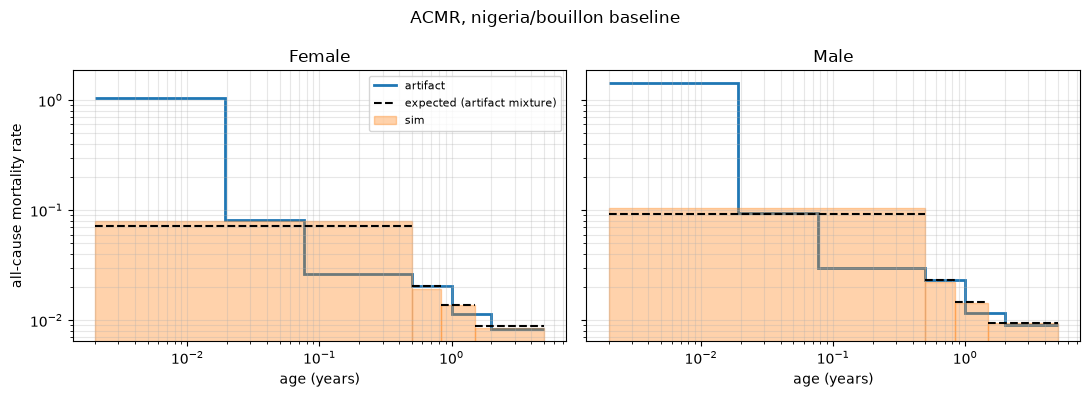

In [2]:
deaths = pd.read_parquet(results_dir + "deaths")
pt = pd.read_parquet(results_dir + "person_time_population")
cols = ["maternal_scenario", "child_scenario", "sex", "age_group"]
acmr = (deaths.groupby(cols).value.sum() / pt.groupby(cols).value.sum()).rename("sim")
acmr = acmr.xs(("baseline", "baseline")).reset_index()
sim_bins = {
    "0_to_5_months": (0.0, 0.5),
    "6_to_9_months": (0.5, 10 / 12),
    "10_to_17_months": (10 / 12, 1.5),
    "18_to_59_months": (1.5, 5.0),
}

art_acmr = art.load("cause.all_causes.cause_specific_mortality_rate")["draw_0"].reset_index()
art_acmr = art_acmr[art_acmr.age_start < 5].sort_values("age_start")


def mixture_rate(art_sex, lo, hi):
    """Deaths / person-time over [lo, hi) under the artifact's piecewise-constant hazard."""
    total_deaths = total_pt = 0.0
    survival = 1.0  # conditional on reaching lo; the constant cancels in the ratio
    for _, row in art_sex.iterrows():
        a, b = max(row.age_start, lo), min(row.age_end, hi)
        if a >= b:
            continue
        died = survival * (1 - np.exp(-row.draw_0 * (b - a)))
        total_deaths += died
        total_pt += died / row.draw_0
        survival -= died
    return total_deaths / total_pt


X_MIN = 2e-3
fig, axes = plt.subplots(1, 2, figsize=(11, 4), sharey=True)
for ax, sex in zip(axes, ["Female", "Male"]):
    a = art_acmr[art_acmr.sex == sex]
    edges = np.append(a.age_start.values, a.age_end.values[-1]).clip(min=X_MIN)
    ax.stairs(a.draw_0.values, edges, baseline=None, color="C0", lw=2, label="artifact")
    for i, (age_group, (lo, hi)) in enumerate(sim_bins.items()):
        v = acmr.loc[(acmr.sex == sex) & (acmr.age_group == age_group), "sim"].iloc[0]
        ax.bar(max(lo, X_MIN), v, width=hi - max(lo, X_MIN), align="edge",
               color="C1", alpha=0.35, edgecolor="C1", label="sim" if i == 0 else None)
        ax.hlines(mixture_rate(a, lo, hi), max(lo, X_MIN), hi, color="k", ls="--",
                  lw=1.5, label="expected (artifact mixture)" if i == 0 else None)
    ax.set_xscale("log")
    ax.set_yscale("log")
    ax.grid(which="both", alpha=0.3)
    ax.set_title(sex)
    ax.set_xlabel("age (years)")
axes[0].set_ylabel("all-cause mortality rate")
axes[0].legend(fontsize=8)
fig.suptitle(f"ACMR, {location}/{vehicle} baseline")
fig.tight_layout()